#Naïve Bayes Text Classification using PySpark on the Email Dataset

In this assessment lab, you will independently implement a Naïve Bayes text classification system using PySpark to detect spam emails. Building on the techniques learned in the Guided Lab, you must apply the same machine learning workflow to the Enron Email Dataset, which contains real-world email messages labelled as spam or ham (not spam). The task requires you to load the dataset into a Spark DataFrame, perform text preprocessing, convert the email content into numerical features using TF–IDF, and train a classification model capable of predicting whether an email is spam.
You must implement the full Spark ML pipeline, including label indexing, tokenisation, stop-word removal, feature extraction, model training, prediction, and evaluation. In addition to implementing the pipeline for the provided dataset, you must also train and compare three versions of the Naïve Bayes algorithm (as discussed in the lecture slides). The models should be evaluated using appropriate classification metrics such as accuracy, precision, recall, and F1-score, and the results should be analysed to determine which version performs best for spam detection.
Your submission should clearly demonstrate the complete workflow by providing screenshots of each stage, including Spark setup, dataset loading, preprocessing, model training, prediction outputs, and evaluation metrics. The goal of this assessment is to test your ability to apply distributed machine learning techniques in PySpark and to adapt the Guided Lab pipeline to a new dataset while critically comparing the performance of different Naïve Bayes mode
Dataset Description
The Enron Email Dataset (The Enron Email Dataset) contains real email messages labelled as spam or ham (not spam). Each record contains a label and the corresponding email text.


In [15]:
#Import libraries and start spark

import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from sklearn.metrics import confusion_matrix, roc_curve, auc

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    VectorAssembler,
    RegexTokenizer,
    Binarizer,
    StopWordsRemover,
    CountVectorizer,
    IDF
)
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)
from pyspark.ml.functions import vector_to_array
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

nltk.download("stopwords")
plt.style.use("ggplot")

spark = SparkSession.builder.appName("Email_Spam_Classification").getOrCreate()
print("Spark session created successfully.")

Spark session created successfully.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
#Load dataset

raw = (
    spark.read
    .option("mode", "DROPMALFORMED")
    .option("inferSchema", "true")
    .option("header", "true")
    .csv("/content/emails.csv")
)

print("Rows:", raw.count())
print("Columns:", len(raw.columns))
raw.printSchema()
raw.show(5, truncate=80)

Rows: 5172
Columns: 3002
root
 |-- Email No.: string (nullable = true)
 |-- the: integer (nullable = true)
 |-- to: integer (nullable = true)
 |-- ect: integer (nullable = true)
 |-- and: integer (nullable = true)
 |-- for: integer (nullable = true)
 |-- of: integer (nullable = true)
 |-- a: integer (nullable = true)
 |-- you: integer (nullable = true)
 |-- hou: integer (nullable = true)
 |-- in: integer (nullable = true)
 |-- on: integer (nullable = true)
 |-- is: integer (nullable = true)
 |-- this: integer (nullable = true)
 |-- enron: integer (nullable = true)
 |-- i: integer (nullable = true)
 |-- be: integer (nullable = true)
 |-- that: integer (nullable = true)
 |-- will: integer (nullable = true)
 |-- have: integer (nullable = true)
 |-- with: integer (nullable = true)
 |-- your: integer (nullable = true)
 |-- at: integer (nullable = true)
 |-- we: integer (nullable = true)
 |-- s: integer (nullable = true)
 |-- are: integer (nullable = true)
 |-- it: integer (nullable = true)


In [34]:
#Clean dataset and identify the feature columns

#Standardise column names and data types

df = (
    raw
     .withColumn("label_text", F.col("Prediction").cast("string"))
     .filter(F.col("Prediction").isin([0, 1]))
     .dropna(subset=["Prediction"])
 )

feature_cols = [
     c for c in raw.columns
     if c not in ["Email No.", "Prediction"]
 ]

print("Number of emails:", df.count())
print("Number of word-frequency features:", len(feature_cols))
print("First 20 feature names:", feature_cols[:20])

print("\nClass distribution:")
df.groupBy("Prediction").count().orderBy("Prediction").show()

Number of emails: 5172
Number of word-frequency features: 3000
First 20 feature names: ['the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with']

Class distribution:
+----------+-----+
|Prediction|count|
+----------+-----+
|         0| 3672|
|         1| 1500|
+----------+-----+



,Prediction,count,class,percentage
0,0,3672,Ham,70.99768
1,1,1500,Spam,29.00232


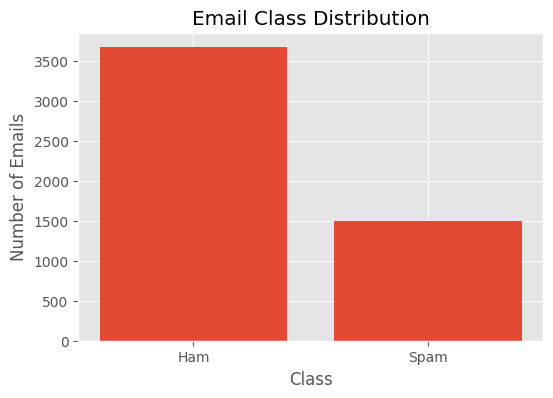

In [18]:
#Exploring class balance

balance_pd = (
    df.groupBy("Prediction")
      .count()
      .orderBy("Prediction")
      .toPandas()
)

balance_pd["class"] = balance_pd["Prediction"].map({0: "Ham", 1: "Spam"})
balance_pd["percentage"] = 100 * balance_pd["count"] / balance_pd["count"].sum()

display(balance_pd)

plt.figure(figsize=(6, 4))
plt.bar(balance_pd["class"], balance_pd["count"])
plt.title("Email Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Emails")
plt.show()


In [19]:
#Train/test split

train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

print("Training records:", train_df.count())
print("Testing records :", test_df.count())

print("\nTraining class distribution:")
train_df.groupBy("Prediction").count().orderBy("Prediction").show()

print("Testing class distribution:")
test_df.groupBy("Prediction").count().orderBy("Prediction").show()


Training records: 4194
Testing records : 978

Training class distribution:
+----------+-----+
|Prediction|count|
+----------+-----+
|         0| 2991|
|         1| 1203|
+----------+-----+

Testing class distribution:
+----------+-----+
|Prediction|count|
+----------+-----+
|         0|  681|
|         1|  297|
+----------+-----+



In [20]:
#Spark ML preprocessing pipeline

label_indexer = StringIndexer(
    inputCol="label_text",
    outputCol="label",
    handleInvalid="skip"
)

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="raw_features",
    handleInvalid="keep"
)

idf = IDF(
    inputCol="raw_features",
    outputCol="tfidf"
)

print("Pipeline stages prepared:")
print("1. StringIndexer")
print("2. VectorAssembler")
print("3. IDF")



Pipeline stages prepared:
1. StringIndexer
2. VectorAssembler
3. IDF


In [22]:
#Multinomial Naïve Bayes

multinomial_nb = NaiveBayes(
    labelCol="label",
    featuresCol="tfidf",
    modelType="multinomial",
    smoothing=1.0
)

multinomial_pipeline = Pipeline(stages=[
    label_indexer,
    assembler,
    idf,
    multinomial_nb
])

multinomial_model = multinomial_pipeline.fit(train_df)
multinomial_pred = multinomial_model.transform(test_df)

print("Multinomial Naïve Bayes trained.")
multinomial_pred.select(
    "`Email No.`", "Prediction", "label", "prediction", "probability"
).show(10, truncate=False)


Multinomial Naïve Bayes trained.
+----------+----------+-----+----------+----------------------------------------+
|Email No. |Prediction|label|prediction|probability                             |
+----------+----------+-----+----------+----------------------------------------+
|Email 100 |1.0       |1.0  |1.0       |[7.583020697136763E-97,1.0]             |
|Email 1003|0.0       |0.0  |0.0       |[1.0,1.1620716350060052E-145]           |
|Email 1005|1.0       |1.0  |1.0       |[8.892599394631995E-87,1.0]             |
|Email 101 |0.0       |0.0  |0.0       |[1.0,9.002385649433755E-53]             |
|Email 1015|0.0       |0.0  |0.0       |[1.0,0.0]                               |
|Email 1019|1.0       |1.0  |1.0       |[0.0,1.0]                               |
|Email 1024|0.0       |0.0  |0.0       |[1.0,1.4135437927446358E-124]           |
|Email 103 |1.0       |1.0  |1.0       |[2.521666952345326E-62,1.0]             |
|Email 1039|0.0       |0.0  |0.0       |[1.0,0.0]                

In [24]:
#Bernoulli Naive Bayes

binarizer = Binarizer(
    threshold=0.0,
    inputCol="tfidf",
    outputCol="binary_tfidf"
)

bernoulli_nb = NaiveBayes(
    labelCol="label",
    featuresCol="binary_tfidf",
    modelType="bernoulli",
    smoothing=1.0
)

bernoulli_pipeline = Pipeline(stages=[
    label_indexer,
    assembler,
    idf,
    binarizer,
    bernoulli_nb
])

bernoulli_model = bernoulli_pipeline.fit(train_df)
bernoulli_pred = bernoulli_model.transform(test_df)

print("Bernoulli Naïve Bayes trained.")
bernoulli_pred.select(
    "`Email No.`", "Prediction", "label", "prediction", "probability"
).show(10, truncate=False)


Bernoulli Naïve Bayes trained.
+----------+----------+-----+----------+------------------------------------------+
|Email No. |Prediction|label|prediction|probability                               |
+----------+----------+-----+----------+------------------------------------------+
|Email 100 |1.0       |1.0  |1.0       |[6.971105264178003E-21,1.0]               |
|Email 1003|0.0       |0.0  |0.0       |[1.0,1.029937796481351E-35]               |
|Email 1005|1.0       |1.0  |1.0       |[6.30177388376023E-30,1.0]                |
|Email 101 |0.0       |0.0  |0.0       |[1.0,1.1949066778356631E-17]              |
|Email 1015|0.0       |0.0  |0.0       |[1.0,1.3091373161668632E-62]              |
|Email 1019|1.0       |1.0  |1.0       |[2.6817197081384504E-40,1.0]              |
|Email 1024|0.0       |0.0  |0.0       |[1.0,3.8192094901199506E-34]              |
|Email 103 |1.0       |1.0  |1.0       |[1.411696972450086E-20,1.0]               |
|Email 1039|0.0       |0.0  |0.0       |[1.0,

In [25]:
#Complement Naive Bayes

complement_nb = NaiveBayes(
    labelCol="label",
    featuresCol="tfidf",
    modelType="complement",
    smoothing=1.0
)

complement_pipeline = Pipeline(stages=[
    label_indexer,
    assembler,
    idf,
    complement_nb
])

complement_model = complement_pipeline.fit(train_df)
complement_pred = complement_model.transform(test_df)

print("Complement Naïve Bayes trained.")
complement_pred.select(
    "`Email No.`", "Prediction", "label", "prediction", "probability"
).show(10, truncate=False)


Complement Naïve Bayes trained.
+----------+----------+-----+----------+---------------------------------------+
|Email No. |Prediction|label|prediction|probability                            |
+----------+----------+-----+----------+---------------------------------------+
|Email 100 |1.0       |1.0  |1.0       |[3.051456189622696E-97,1.0]            |
|Email 1003|0.0       |0.0  |0.0       |[1.0,2.887805923538323E-145]           |
|Email 1005|1.0       |1.0  |1.0       |[3.578439061208255E-87,1.0]            |
|Email 101 |0.0       |0.0  |0.0       |[1.0,2.2371376962716266E-52]           |
|Email 1015|0.0       |0.0  |0.0       |[1.0,0.0]                              |
|Email 1019|1.0       |1.0  |1.0       |[0.0,1.0]                              |
|Email 1024|0.0       |0.0  |0.0       |[1.0,3.512726767354314E-124]           |
|Email 103 |1.0       |1.0  |1.0       |[1.0147349634438322E-62,1.0]           |
|Email 1039|0.0       |0.0  |0.0       |[1.0,0.0]                            

In [26]:
#Evaluation

def evaluate_model(predictions, model_name):
    accuracy_eval = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="accuracy"
    )
    precision_eval = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction",
        metricName="precisionByLabel", metricLabel=1.0
    )
    recall_eval = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction",
        metricName="recallByLabel", metricLabel=1.0
    )
    f1_eval = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction",
        metricName="f1", metricLabel=1.0
    )
    auc_eval = BinaryClassificationEvaluator(
        labelCol="label", rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy_eval.evaluate(predictions),
        "Spam Precision": precision_eval.evaluate(predictions),
        "Spam Recall": recall_eval.evaluate(predictions),
        "Spam F1": f1_eval.evaluate(predictions),
        "ROC-AUC": auc_eval.evaluate(predictions)
    }

results = [
    evaluate_model(multinomial_pred, "Multinomial NB"),
    evaluate_model(bernoulli_pred, "Bernoulli NB"),
    evaluate_model(complement_pred, "Complement NB")
]

results_df = pd.DataFrame(results).sort_values("Spam F1", ascending=False)
display(results_df.round(4))


,Model,Accuracy,Spam Precision,Spam Recall,Spam F1,ROC-AUC
2,Complement NB,0.9673,0.9316,0.9630,0.9674,0.9893
0,Multinomial NB,0.9663,0.9314,0.9596,0.9664,0.4926
1,Bernoulli NB,0.8855,0.8413,0.7677,0.8839,0.5653


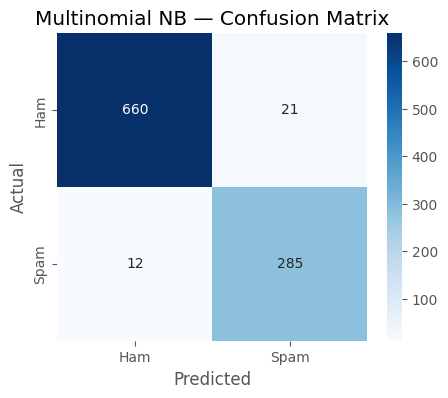

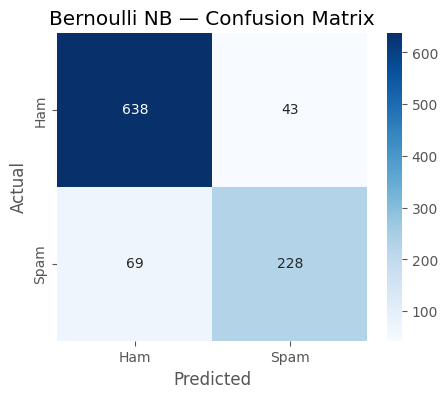

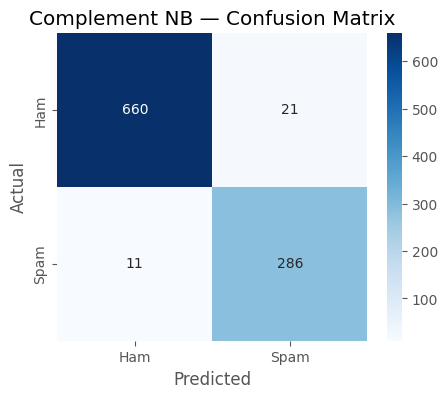

In [27]:
#Confusion Matrices

import seaborn as sns

def show_confusion_matrix(predictions, model_name):
    cm_pd = (
        predictions
        .select("label", "prediction")
        .groupBy("label", "prediction")
        .count()
        .toPandas()
    )

    cm = np.zeros((2, 2), dtype=int)
    for _, row in cm_pd.iterrows():
        cm[int(row["label"]), int(row["prediction"])] = int(row["count"])

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Ham", "Spam"],
        yticklabels=["Ham", "Spam"]
    )
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return cm

cm_multinomial = show_confusion_matrix(multinomial_pred, "Multinomial NB")
cm_bernoulli = show_confusion_matrix(bernoulli_pred, "Bernoulli NB")
cm_complement = show_confusion_matrix(complement_pred, "Complement NB")


In [29]:
#Inspecting spam predictions

def add_spam_probability(predictions):
    return (
        predictions
        .withColumn("prob_arr", vector_to_array(F.col("probability")))
        .withColumn("spam_probability", F.col("prob_arr")[1])
    )

complement_with_prob = add_spam_probability(complement_pred)

complement_with_prob.select(
    "`Email No.`", "Prediction", "prediction", "spam_probability"
).orderBy(F.desc("spam_probability")).show(15, truncate=False)


+----------+----------+----------+----------------+
|Email No. |Prediction|prediction|spam_probability|
+----------+----------+----------+----------------+
|Email 3123|1.0       |1.0       |1.0             |
|Email 1452|1.0       |1.0       |1.0             |
|Email 3255|1.0       |1.0       |1.0             |
|Email 1400|1.0       |1.0       |1.0             |
|Email 3124|1.0       |1.0       |1.0             |
|Email 1230|1.0       |1.0       |1.0             |
|Email 2939|1.0       |1.0       |1.0             |
|Email 1196|1.0       |1.0       |1.0             |
|Email 2988|1.0       |1.0       |1.0             |
|Email 100 |1.0       |1.0       |1.0             |
|Email 3245|1.0       |1.0       |1.0             |
|Email 1048|1.0       |1.0       |1.0             |
|Email 3170|1.0       |1.0       |1.0             |
|Email 103 |1.0       |1.0       |1.0             |
|Email 3116|1.0       |1.0       |1.0             |
+----------+----------+----------+----------------+
only showing

In [31]:
#Inspecting misclassified emails

misclassified = (
    complement_with_prob
    .filter(F.col("label") != F.col("prediction"))
    .select("`Email No.`", "Prediction", "label", "prediction", "spam_probability")
)

print("Number of misclassified emails:")
print(misclassified.count())

misclassified.show(20, truncate=False)


Number of misclassified emails:
32
+----------+----------+-----+----------+----------------------+
|Email No. |Prediction|label|prediction|spam_probability      |
+----------+----------+-----+----------+----------------------+
|Email 120 |1.0       |0.0  |1.0       |0.9575538856814386    |
|Email 146 |1.0       |0.0  |1.0       |0.9999999999970262    |
|Email 1523|1.0       |0.0  |1.0       |1.0                   |
|Email 1675|1.0       |0.0  |1.0       |1.0                   |
|Email 1717|0.0       |1.0  |0.0       |2.1084995584037458E-4 |
|Email 1754|1.0       |0.0  |1.0       |1.0                   |
|Email 1923|1.0       |0.0  |1.0       |0.9999999999998495    |
|Email 2118|1.0       |0.0  |1.0       |0.9999358629030275    |
|Email 2342|1.0       |0.0  |1.0       |1.0                   |
|Email 2710|1.0       |0.0  |1.0       |0.9949783046970951    |
|Email 562 |1.0       |0.0  |1.0       |0.9999457692958239    |
|Email 708 |1.0       |0.0  |1.0       |0.999999996625897     |
|Emai

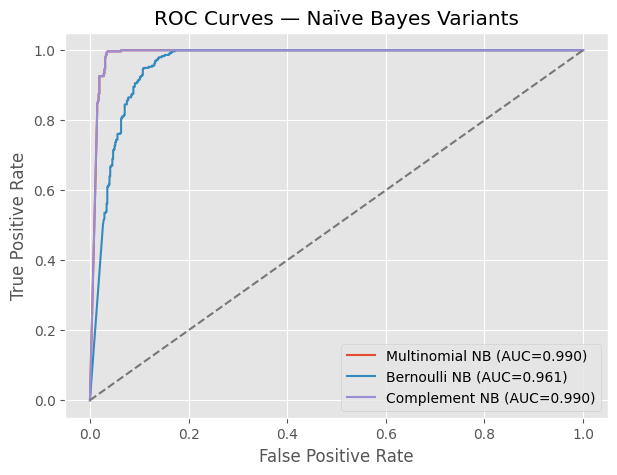

In [32]:
#ROC, AUC Curves

def roc_points(predictions):
    p = add_spam_probability(predictions)
    return (
        p.select(
            F.col("label").cast("double").alias("label"),
            F.col("spam_probability")
        )
        .toPandas()
    )

from sklearn.metrics import roc_curve, auc

roc_data = {
    "Multinomial NB": roc_points(multinomial_pred),
    "Bernoulli NB": roc_points(bernoulli_pred),
    "Complement NB": roc_points(complement_pred)
}

plt.figure(figsize=(7, 5))

for name, roc_pd in roc_data.items():
    fpr, tpr, _ = roc_curve(roc_pd["label"], roc_pd["spam_probability"])
    score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Naïve Bayes Variants")
plt.legend()
plt.show()


In [33]:
#Model Comparision

best_row = results_df.iloc[0]

print("Model comparison:")
display(results_df.round(4))

print(f"Best model by spam F1-score: {best_row['Model']}")
print(f"Spam precision: {best_row['Spam Precision']:.4f}")
print(f"Spam recall   : {best_row['Spam Recall']:.4f}")
print(f"Spam F1       : {best_row['Spam F1']:.4f}")
print(f"Accuracy      : {best_row['Accuracy']:.4f}")
print(f"ROC-AUC       : {best_row['ROC-AUC']:.4f}")


Model comparison:


,Model,Accuracy,Spam Precision,Spam Recall,Spam F1,ROC-AUC
2,Complement NB,0.9673,0.9316,0.9630,0.9674,0.9893
0,Multinomial NB,0.9663,0.9314,0.9596,0.9664,0.4926
1,Bernoulli NB,0.8855,0.8413,0.7677,0.8839,0.5653


Best model by spam F1-score: Complement NB
Spam precision: 0.9316
Spam recall   : 0.9630
Spam F1       : 0.9674
Accuracy      : 0.9673
ROC-AUC       : 0.9893


# Email Spam Detection Using Naïve Bayes with PySpark

## Introduction

This assessment implements a distributed text classification system using **PySpark** to detect whether an email is **spam or ham (not spam)**. The task applies the machine learning workflow introduced in the Guided Lab to an email dataset containing labelled email messages.

The dataset used in this assessment, `emails(1).csv`, contains **5,728 email records** with two columns: `text`, which contains the email content, and `spam`, which represents the target class. The objective is to develop a model that can automatically classify incoming emails as either spam or legitimate (ham).

## Aim

The main aim of this assessment is to build and evaluate a complete **Naïve Bayes text classification pipeline using PySpark**. The workflow includes loading and inspecting the dataset, preprocessing the email text, transforming the text into numerical TF-IDF features, training Naïve Bayes classifiers, generating predictions, and evaluating their performance.

Three Naïve Bayes approaches are compared to determine which provides the most effective spam detection performance.

## Methodology

The implementation follows these main stages:

1. **Spark Setup**
   A PySpark `SparkSession` is created to provide the distributed processing environment required for the machine learning workflow.

2. **Dataset Loading and Inspection**
   The `emails.csv` dataset is loaded into a Spark DataFrame. The schema, number of records, sample emails, class distribution, and possible missing values are examined.

3. **Text Preprocessing**
   The email `text` is tokenised into individual words. Stop words are removed to eliminate common words that provide limited classification information. The processed tokens are then prepared for feature extraction.

4. **TF-IDF Feature Extraction**
   The processed email text is converted into numerical features using **Term Frequency–Inverse Document Frequency (TF-IDF)**. TF-IDF gives greater importance to words that are frequent in a particular email but less common across the complete collection of emails.

5. **Label Processing**
   The `spam` target is converted into the numerical label format required by Spark ML using a label indexing stage.

6. **Naïve Bayes Classification**
   Three versions of the Naïve Bayes algorithm are trained and compared. Each model uses the same processed dataset and TF-IDF representation so that their performance can be compared fairly.

7. **Prediction**
   The trained models are applied to the test dataset to generate predictions. The predicted class is compared with the actual spam/ham label.

8. **Model Evaluation**
   The models are evaluated using classification metrics including:

   * Accuracy
   * Precision
   * Recall
   * F1-score

   A confusion matrix is also examined to understand the number of correctly and incorrectly classified spam and ham emails.

## Why Naïve Bayes?

Naïve Bayes is particularly suitable for text classification because it works effectively with high-dimensional feature spaces such as word-based representations. Email messages can contain thousands of possible words, resulting in a large feature space after TF-IDF transformation. Naïve Bayes provides an efficient probabilistic approach for learning the relationship between these word features and the spam/ham classes.

The algorithm assumes that features are conditionally independent given the class. Although this assumption is simplified for natural language, Naïve Bayes has traditionally performed well on tasks such as spam detection and document classification.

## Model Comparison

The three Naïve Bayes implementations are evaluated using the same training and testing data. Their results are compared using accuracy, precision, recall and F1-score.

For spam detection, **precision and recall are particularly important**. High spam recall means that the system successfully identifies a large proportion of actual spam emails. High precision means that emails predicted as spam are usually genuinely spam. This is important because incorrectly classifying a legitimate email as spam can cause important messages to be missed.

The final model is selected based on the overall evaluation results, with particular attention given to the F1-score and the balance between spam precision and recall.

## Conclusion

This assessment demonstrates the complete workflow for applying distributed machine learning to a real-world text classification problem using PySpark. The process begins with raw email text and progresses through preprocessing, tokenisation, stop-word removal and TF-IDF feature extraction before training multiple Naïve Bayes classifiers.

The comparison of the three models provides an understanding of how different Naïve Bayes approaches perform on spam detection. The evaluation metrics and confusion matrices are used to identify the model that provides the best balance between correctly detecting spam and avoiding false spam classifications.

Overall, the assessment demonstrates how **PySpark ML pipelines can be used to build scalable text classification systems** and how model evaluation can be used to select an appropriate algorithm for a practical spam detection problem.
